
Model Comparison Table (Test Set Metrics + Train CV):
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0                  MLP  0.756361   0.758288  0.756361  0.755906  0.834919   
1  Logistic Regression  0.749743   0.750117  0.749743  0.749649  0.826403   
2        Random Forest  0.756210   0.758004  0.756210  0.755786  0.834122   
3             CatBoost  0.757954   0.759607  0.757954  0.757568  0.835899   
4             LightGBM  0.757185   0.758879  0.757185  0.756787  0.835451   
5              XGBoost  0.756938   0.758970  0.756938  0.756460  0.835350   

   Mean CV F1  Std CV F1  
0    0.756476   0.001147  
1    0.750133   0.001573  
2    0.756091   0.001673  
3    0.758119   0.001664  
4    0.757660   0.001490  
5    0.757505   0.001401  

Best Model based on Test F1 Score: CatBoost


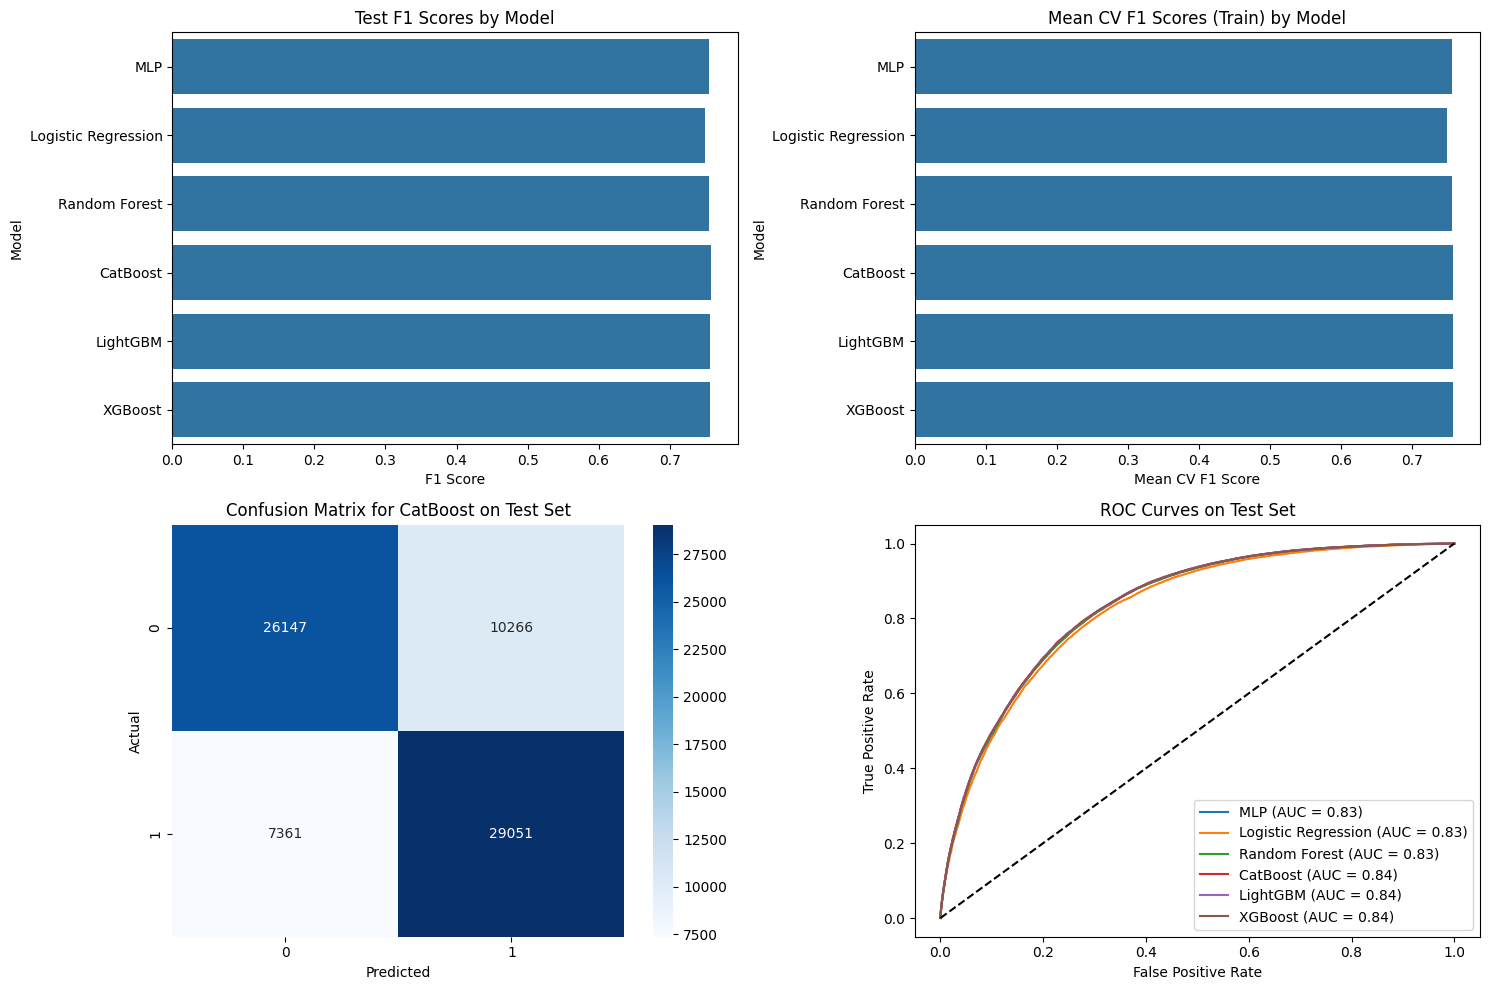


Results saved to 'model_comparison_results.csv'


In [3]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Define paths
TRAIN_PATH = '../data/train-test/train_set.csv'
TEST_PATH = '../data/train-test/test_set.csv'

# Load datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Assuming the target column is named 'target'. Adjust if different.
TARGET_COLUMN = 'has_diabetes'

X_train = train_df.drop(TARGET_COLUMN, axis=1)
y_train = train_df[TARGET_COLUMN]
X_test = test_df.drop(TARGET_COLUMN, axis=1)
y_test = test_df[TARGET_COLUMN]

# Load models and scalers
models = {
    'MLP': joblib.load('../models/mlp_tuned_model.joblib'),
    'Logistic Regression': joblib.load('../models/logistic_regression_tuned_model.joblib'),
    'Random Forest': joblib.load('../models/random_forest_tuned_model.joblib'),
    'CatBoost': joblib.load('../models/catboost_tuned_model.joblib'),
    'LightGBM': joblib.load('../models/lightgbm_tuned_model.joblib'),
    'XGBoost': joblib.load('../models/xgboost_calibrated_model.joblib')
}

scalers = {
    'MLP': joblib.load('../models/standard_scaler_mlp.joblib'),
    'Logistic Regression': joblib.load('../models/standard_scaler_logistic_Tuned.joblib')
}

# Function to evaluate model on test set
def evaluate_model(model, X, y, scaler=None):
    if scaler:
        X = scaler.transform(X)
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
    metrics = {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, average='weighted'),
        'Recall': recall_score(y, y_pred, average='weighted'),
        'F1 Score': f1_score(y, y_pred, average='weighted'),
        'ROC AUC': roc_auc_score(y, y_prob) if y_prob is not None else np.nan
    }
    return metrics, y_pred, y_prob

# Cross-validation on train set
# For models with scalers, we'll use Pipeline to avoid data leakage
cv_scores = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name in scalers:
        # Recreate pipeline for CV (assuming StandardScaler was used)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model.__class__(**model.get_params()))  # Recreate model with same params
        ])
        scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_weighted')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted')
    cv_scores[name] = {
        'Mean CV F1': scores.mean(),
        'Std CV F1': scores.std()
    }

# Evaluate on test set
results = []
test_predictions = {}
for name, model in models.items():
    scaler = scalers.get(name)
    metrics, y_pred, y_prob = evaluate_model(model, X_test, y_test, scaler)
    metrics['Mean CV F1'] = cv_scores[name]['Mean CV F1']
    metrics['Std CV F1'] = cv_scores[name]['Std CV F1']
    metrics['Model'] = name
    results.append(metrics)
    test_predictions[name] = (y_pred, y_prob)

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Mean CV F1', 'Std CV F1']]

# Print results
print("\nModel Comparison Table (Test Set Metrics + Train CV):")
print(results_df)

# Find best model based on Test F1 Score (or adjust criterion)
best_model = results_df.loc[results_df['F1 Score'].idxmax()]['Model']
print(f"\nBest Model based on Test F1 Score: {best_model}")

# Visualizations
plt.figure(figsize=(15, 10))

# Bar plot for Test F1 Scores
plt.subplot(2, 2, 1)
sns.barplot(x='F1 Score', y='Model', data=results_df)
plt.title('Test F1 Scores by Model')
plt.xlabel('F1 Score')
plt.ylabel('Model')

# Bar plot for Mean CV F1 scores
plt.subplot(2, 2, 2)
sns.barplot(x='Mean CV F1', y='Model', data=results_df)
plt.title('Mean CV F1 Scores (Train) by Model')
plt.xlabel('Mean CV F1 Score')
plt.ylabel('Model')

# Confusion Matrix for the best model on test
plt.subplot(2, 2, 3)
y_pred, _ = test_predictions[best_model]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix for {best_model} on Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ROC Curve for models with predict_proba on test
plt.subplot(2, 2, 4)
from sklearn.metrics import roc_curve
for name in models:
    _, y_prob = test_predictions[name]
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves on Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv'")